#### **Comparison Chart**

##### Import Necessary Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import cohen_kappa_score
import json

#### **Sentiment Labelling**

In [ ]:
labelling_2020 = pd.read_csv('https://drive.google.com/uc?export=download&id=1YaZUrJZBKC1pYoR-iFtLpzs8HxrX1Whc')
labelling_2021 = pd.read_csv('https://drive.google.com/uc?export=download&id=1A5tZZXLHqnfdES14NkLZUIhFavO276Kw')
labelling_2022 = pd.read_csv('https://drive.google.com/uc?export=download&id=1ssrYURMLH4TBqbtvyHrNFDUEX14QbvoI')
labelling_2023 = pd.read_csv('https://drive.google.com/uc?export=download&id=1buxWpuAq5susNVCHY6afcs2elCvGo8Qf')
labelling_2024 = pd.read_csv('https://drive.google.com/uc?export=download&id=1g6DzLfvCodEeDYll4d2PO3EvvDdE4DnG')
labelling_2025 = pd.read_csv('https://drive.google.com/uc?export=download&id=1MyU_tNKCqUXifgw1NxRBgm-w9gKR2jhC')

#### **Topic Modelling Dataset**

In [ ]:
topic_model_2020 = pd.read_json(
    'https://drive.google.com/uc?export=download&id=1CrKuQcTt3fAgvQ2WwaeMGtdq_hwcXY4l'
)

topic_model_2021 = pd.read_json(
    'https://drive.google.com/uc?export=download&id=1Cdrdiee-ja8V7fYn4y0-KBiTvXddPol5'
)

topic_model_2022 = pd.read_json(
    'https://drive.google.com/uc?export=download&id=1mYyEN4lVkz-jAKr6J8lQ3oyXwAMqPith'
)

topic_model_2023 = pd.read_json(
    'https://drive.google.com/uc?export=download&id=1S1p5TPSPWbqemKQIpv0QtYlqZJmihjaP'
)

topic_model_2024 = pd.read_json(
    'https://drive.google.com/uc?export=download&id=10nf-3zSwFk-1MnZ-5_H6ttoJsFXnEqlr'
)

topic_model_2025 = pd.read_json(
    'https://drive.google.com/uc?export=download&id=18Wtx7JpnKXwsEarR8TO0sO1GeUe1Sl9c'
)

#### let create a function that takes a sentiment label (column name) and visualises how sentiment changes over time from 2020 to 2025. It counts the number of Positive, Negative, and Neutral entries for each year, stores the results in a DataFrame, and displays them as a grouped bar chart. Each bar is annotated with both the raw count and its percentage contribution for that year, making trends easy to interpret at a glance. Finally, the chart is saved as a high-resolution image for reporting or presentation purposes.

In [ ]:
def general_load(labelling_name):
  data = {
      'year': [2020, 2021, 2022, 2023, 2024, 2025],
      'positive': [labelling_2020[f'{labelling_name}'].value_counts()['Positive'], labelling_2021[f'{labelling_name}'].value_counts()['Positive'], labelling_2022[f'{labelling_name}'].value_counts()['Positive'], labelling_2023[f'{labelling_name}'].value_counts()['Positive'], labelling_2024[f'{labelling_name}'].value_counts()['Positive'], labelling_2025[f'{labelling_name}'].value_counts()['Positive']],
      'negative': [labelling_2020[f'{labelling_name}'].value_counts()['Negative'], labelling_2021[f'{labelling_name}'].value_counts()['Negative'], labelling_2022[f'{labelling_name}'].value_counts()['Negative'], labelling_2023[f'{labelling_name}'].value_counts()['Negative'], labelling_2024[f'{labelling_name}'].value_counts()['Negative'], labelling_2025[f'{labelling_name}'].value_counts()['Negative']],
      'neutral': [labelling_2020[f'{labelling_name}'].value_counts()['Neutral'], labelling_2021[f'{labelling_name}'].value_counts()['Neutral'], labelling_2022[f'{labelling_name}'].value_counts()['Neutral'], labelling_2023[f'{labelling_name}'].value_counts()['Neutral'], labelling_2024[f'{labelling_name}'].value_counts()['Neutral'], labelling_2025[f'{labelling_name}'].value_counts()['Neutral']]
  }

  df = pd.DataFrame(data)

  years = df['year']
  positive = df['positive']
  negative = df['negative']
  neutral = df['neutral']

  x = np.arange(len(years))
  width = 0.28

  plt.figure(figsize=(15, 6))

  bars_pos = plt.bar(x - width, positive, width, label='Positive', color='green')
  bars_neg = plt.bar(x, negative, width, label='Negative', color='red')
  bars_neu = plt.bar(x + width, neutral, width, label='Neutral', color='gray')

  plt.xlabel("Years")
  plt.ylabel("Sentiment Count")
  plt.title(f"Grouped Bar Chart of {labelling_name} per Year")
  plt.xticks(x, years)
  plt.legend()

  def add_labels(bars, counts):
      for bar, count, year in zip(bars, counts, years):
          total = df.loc[df['year'] == year, ['positive','negative','neutral']].sum(axis=1).values[0]
          pct = (count / total) * 100

          height = bar.get_height()
          plt.text(
              bar.get_x() + bar.get_width() / 2,
              height + 30,
              f"{count}\n({pct:.1f}%)",
              ha='center',
              va='bottom',
              fontsize=10,
              fontweight='bold'
          )

  add_labels(bars_pos, positive)
  add_labels(bars_neg, negative)
  add_labels(bars_neu, neutral)

  plt.savefig(f"{labelling_name}_sentiment_per_year.png", dpi=300, bbox_inches='tight')
  plt.show()


#### **Vader For 6 Years Result**

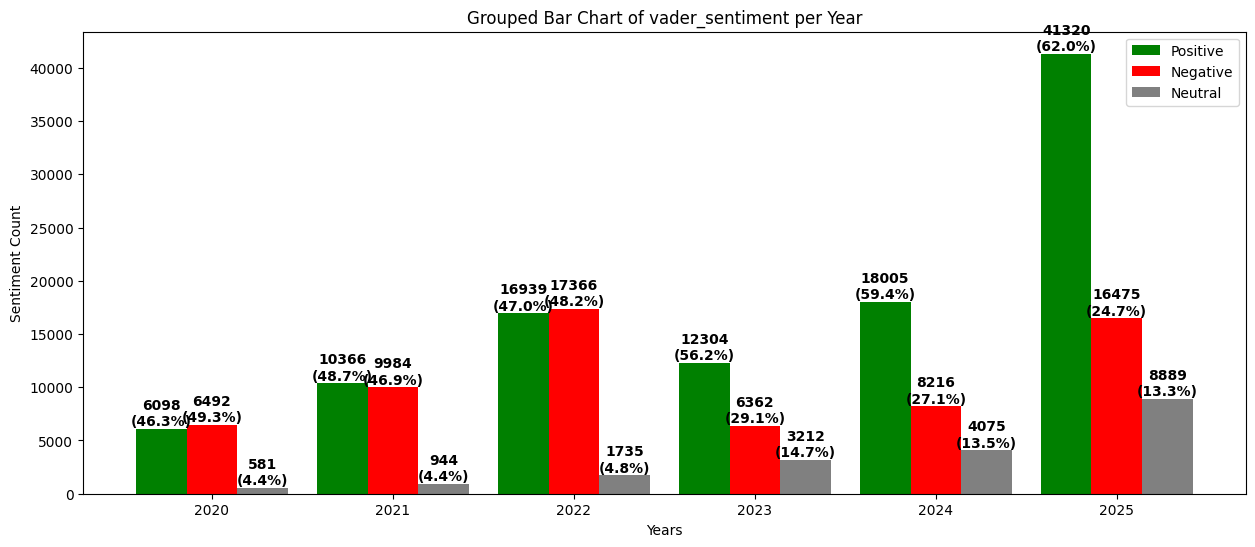

In [ ]:
general_load('vader_sentiment')

#### **TextBlob For 6 Years Result**

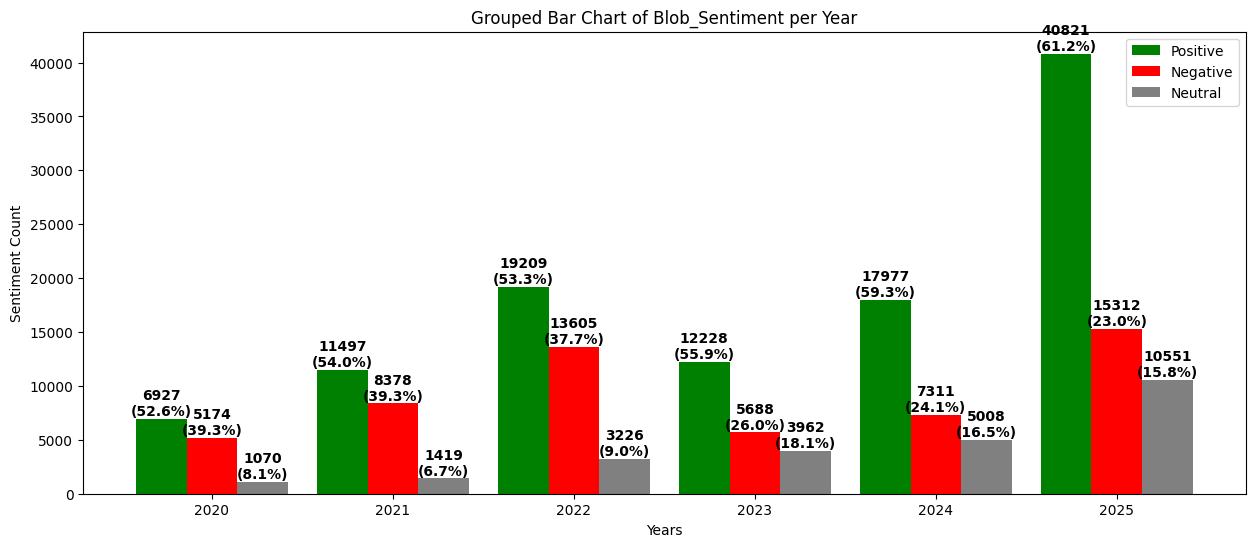

In [ ]:
general_load('Blob_Sentiment')

### **Transformer for 6 years**

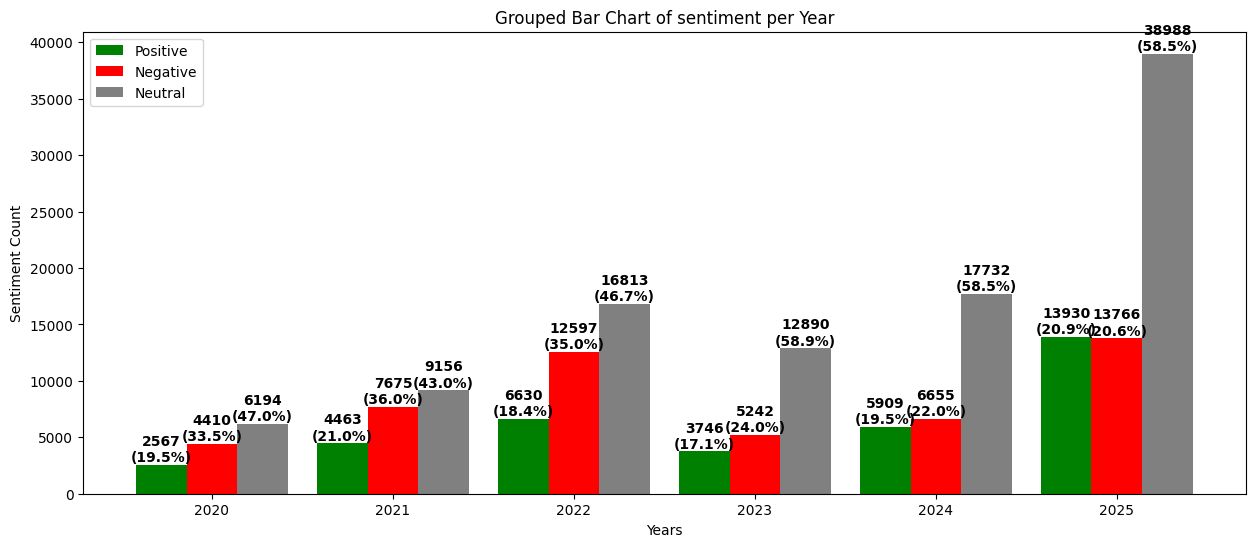

In [ ]:
general_load('sentiment')

#### **The Comparison Final Result**

In [ ]:
def plot_avg_confidence_per_year():
    data = {
        'year': [2020, 2021, 2022, 2023, 2024, 2025],
        'VADER': [
            labelling_2020['vader_strength'].mean(),
            labelling_2021['vader_strength'].mean(),
            labelling_2022['vader_strength'].mean(),
            labelling_2023['vader_strength'].mean(),
            labelling_2024['vader_strength'].mean(),
            labelling_2025['vader_strength'].mean()
        ],
        'TextBlob': [
            labelling_2020['textblob_strength'].mean(),
            labelling_2021['textblob_strength'].mean(),
            labelling_2022['textblob_strength'].mean(),
            labelling_2023['textblob_strength'].mean(),
            labelling_2024['textblob_strength'].mean(),
            labelling_2025['textblob_strength'].mean()
        ],
        'Transformer': [
            labelling_2020['transformer_strength'].mean(),
            labelling_2021['transformer_strength'].mean(),
            labelling_2022['transformer_strength'].mean(),
            labelling_2023['transformer_strength'].mean(),
            labelling_2024['transformer_strength'].mean(),
            labelling_2025['transformer_strength'].mean()
        ]
    }

    df_conf = pd.DataFrame(data)

    years = df_conf['year']
    vader = df_conf['VADER']
    textblob = df_conf['TextBlob']
    transformer = df_conf['Transformer']

    x = np.arange(len(years))
    width = 0.25

    plt.figure(figsize=(12, 6))

    bars_vader = plt.bar(x - width, vader, width, label='VADER', color='skyblue')
    bars_blob = plt.bar(x,         textblob, width, label='TextBlob', color='orange')
    bars_trans = plt.bar(x + width, transformer, width, label='Transformer', color='green')

    plt.title("Average Confidence Levels of Sentiment Models per Year",
              fontsize=14, fontweight='bold')
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Average Confidence", fontsize=12)
    plt.xticks(x, years)
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    def add_labels(bars, values):
        for bar, value in zip(bars, values):
            percent = value * 100
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.03,  # a bit above the bar
                f"{value:.2f}\n({percent:.1f}%)",
                ha='center', va='bottom',
                fontsize=9, fontweight='bold'
            )

    add_labels(bars_vader, vader)
    add_labels(bars_blob, textblob)
    add_labels(bars_trans, transformer)

    plt.tight_layout()

    plt.savefig("Average_confidence.png", dpi=300, bbox_inches='tight')
    plt.show()

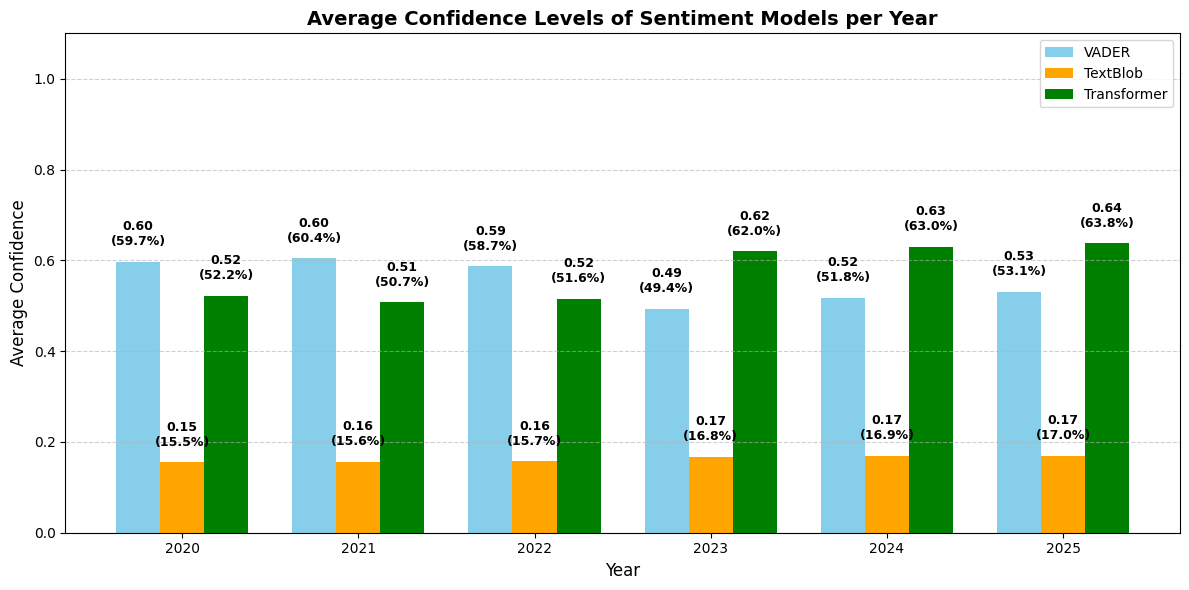

In [ ]:
plot_avg_confidence_per_year()

#### **Kappa Rules**

In [ ]:
def interpret_kappa(k):
    if k < 0.20:
        return "Poor"
    elif k < 0.41:
        return "Fair"
    elif k < 0.61:
        return "Moderate"
    elif k < 0.81:
        return "Good"
    else:
        return "Very Good"

In [ ]:
def kappa_table_per_year():
    years = [2020, 2021, 2022, 2023, 2024, 2025]
    dfs = [labelling_2020, labelling_2021, labelling_2022,
           labelling_2023, labelling_2024, labelling_2025]

    k_vader_blob = []
    k_vader_trans = []
    k_blob_trans  = []

    for df in dfs:
        k_vb = cohen_kappa_score(df['vader_sentiment'], df['Blob_Sentiment'])
        k_vt = cohen_kappa_score(df['vader_sentiment'], df['sentiment'])
        k_bt = cohen_kappa_score(df['Blob_Sentiment'], df['sentiment'])

        k_vader_blob.append(k_vb)
        k_vader_trans.append(k_vt)
        k_blob_trans.append(k_bt)

    kappa_df = pd.DataFrame({
        'Year': years,
        'VADER vs TextBlob': k_vader_blob,
        'V-TB Interpretation': [interpret_kappa(k) for k in k_vader_blob],
        'VADER vs Transformer': k_vader_trans,
        'V-TF Interpretation': [interpret_kappa(k) for k in k_vader_trans],
        'TextBlob vs Transformer': k_blob_trans,
        'TB-TF Interpretation': [interpret_kappa(k) for k in k_blob_trans],
    })

    numeric_cols = ['VADER vs TextBlob', 'VADER vs Transformer', 'TextBlob vs Transformer']
    kappa_df[numeric_cols] = kappa_df[numeric_cols].round(3)

    return kappa_df

In [ ]:
kappa_table_per_year()

,Year,VADER vs TextBlob,V-TB Interpretation,VADER vs Transformer,V-TF Interpretation,TextBlob vs Transformer,TB-TF Interpretation
0,2020,0.381,Fair,0.095,Poor,0.109,Poor
1,2021,0.416,Moderate,0.102,Poor,0.104,Poor
2,2022,0.383,Fair,0.083,Poor,0.104,Poor
3,2023,0.434,Moderate,0.137,Poor,0.135,Poor
4,2024,0.428,Moderate,0.137,Poor,0.137,Poor
5,2025,0.437,Moderate,0.136,Poor,0.125,Poor


In [ ]:
def save_kappa_table_as_image(df, filename="kappa_table.png"):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.4)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

In [ ]:
kappa_df = kappa_table_per_year()
save_kappa_table_as_image(kappa_df, "kappa_table_per_year.png")

#### **Model Comparison**

In [ ]:
with open("model_results.json", "r") as f:
    data = json.load(f)

display(data)

{'2020': [{'Naive Bayes': [{'accuracy': 0.6849,
     'precision': 0.7254,
     'f1_score': 0.7022,
     'use_class_weight': True,
     'labels': 'vader_sentiment'},
    {'accuracy': 0.609,
     'precision': 0.6354,
     'f1_score': 0.6131,
     'use_class_weight': True,
     'labels': 'sentiment'},
    {'accuracy': 0.7092,
     'precision': 0.7184,
     'f1_score': 0.7123,
     'use_class_weight': True,
     'labels': 'Blob_Sentiment'}]},
  {'SVM': [{'model_name': 'LinearSVC',
     'use_class_weight': True,
     'scores': [0.8061, 0.8094, 0.8077],
     'labels': 'vader_sentiment'},
    {'model_name': 'LinearSVC',
     'use_class_weight': True,
     'scores': [0.712, 0.7134, 0.7124],
     'labels': 'sentiment'},
    {'model_name': 'LinearSVC',
     'use_class_weight': True,
     'scores': [0.8294, 0.8303, 0.8297],
     'labels': 'Blob_Sentiment'},
    {'model_name': 'CNN',
     'use_class_weight': True,
     'scores': [0.7618, 0.7578, 0.7597],
     'labels': 'vader_sentiment'},
    {'mo

In [ ]:
rows = []

for year, model_list in data.items():
    for model_block in model_list:
        for model_name, entries in model_block.items():
            for e in entries:
                label_source = e.get("labels", None)

                if "scores" in e:
                    precision, accuracy, f1 = e["scores"]
                else:
                    accuracy = e["accuracy"]
                    precision = e["precision"]
                    f1 = e["f1_score"]

                rows.append({
                    "year": int(year),
                    "model": model_name,
                    "label_source": label_source,
                    "precision": precision,
                    "accuracy": accuracy,
                    "f1": f1
                })

df = pd.DataFrame(rows)

In [ ]:
label_pretty = {
    "vader_sentiment": "VADER",
    "sentiment": "Transformer labels",
    "Blob_Sentiment": "TextBlob"
}
df["label_nice"] = df["label_source"].map(label_pretty)
display(df.head())

,year,model,label_source,precision,accuracy,f1,label_nice
0,2020,Naive Bayes,vader_sentiment,0.7254,0.6849,0.7022,VADER
1,2020,Naive Bayes,sentiment,0.6354,0.6090,0.6131,Transformer labels
2,2020,Naive Bayes,Blob_Sentiment,0.7184,0.7092,0.7123,TextBlob
3,2020,SVM,vader_sentiment,0.8061,0.8094,0.8077,VADER
4,2020,SVM,sentiment,0.7120,0.7134,0.7124,Transformer labels


In [ ]:
df_main = df[df["label_source"] == "sentiment"].copy()
df_main = df_main.sort_values(["year", "model"])

result_table = df_main[["year", "model", "precision", "accuracy", "f1"]]
print(result_table)

result_table.to_csv("results_table_2020_2025_main_labels.csv", index=False)


    year        model  precision  accuracy      f1
10  2020          CNN     0.7120    0.7134  0.7124
13  2020          CNN     0.7418    0.7339  0.7361
1   2020  Naive Bayes     0.6354    0.6090  0.6131
4   2020          SVM     0.7120    0.7134  0.7124
7   2020          SVM     0.7418    0.7339  0.7361
16  2020  Transformer     0.8441    0.8425  0.8429
25  2021          CNN     0.7564    0.7568  0.7552
19  2021  Naive Bayes     0.6382    0.6220  0.6243
22  2021          SVM     0.7285    0.7288  0.7284
28  2021  Transformer     0.8496    0.8456  0.8462
37  2022          CNN     0.7592    0.7587  0.7587
31  2022  Naive Bayes     0.6349    0.6099  0.6146
34  2022          SVM     0.7431    0.7440  0.7428
40  2022  Transformer     0.8623    0.8596  0.8602
49  2023          CNN     0.8204    0.8104  0.8138
43  2023  Naive Bayes     0.7035    0.6177  0.6297
46  2023          SVM     0.7929    0.7971  0.7941
52  2023  Transformer     0.8809    0.8782  0.8792
61  2024          CNN     0.814

In [ ]:
full_table = df.sort_values(["year", "model", "label_source"])
full_table.to_csv("results_table_all_labels.csv", index=False)

In [ ]:
df_avg = (
    df.groupby(["year", "model", "label_source"])
      .agg({
          "f1": "mean",
          "accuracy": "mean"
      })
      .reset_index()
)

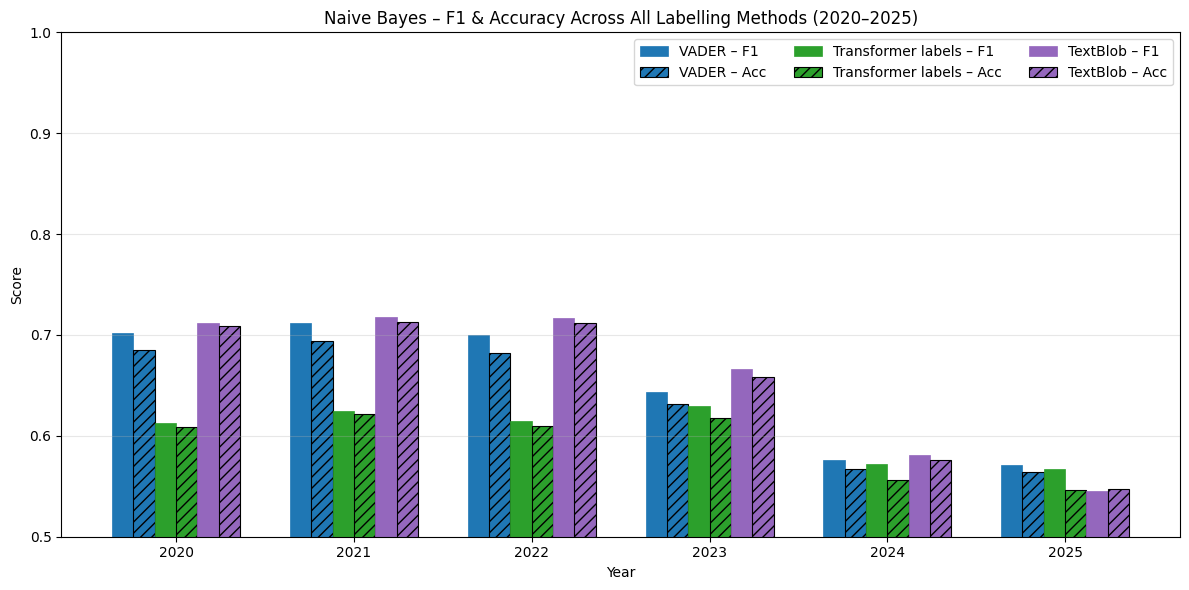

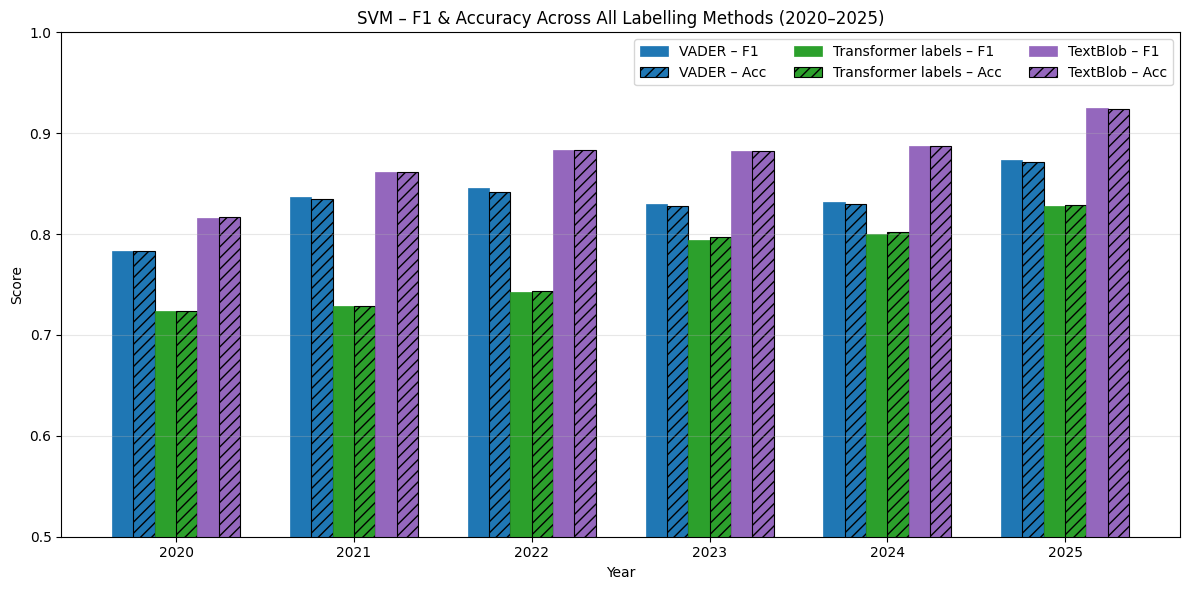

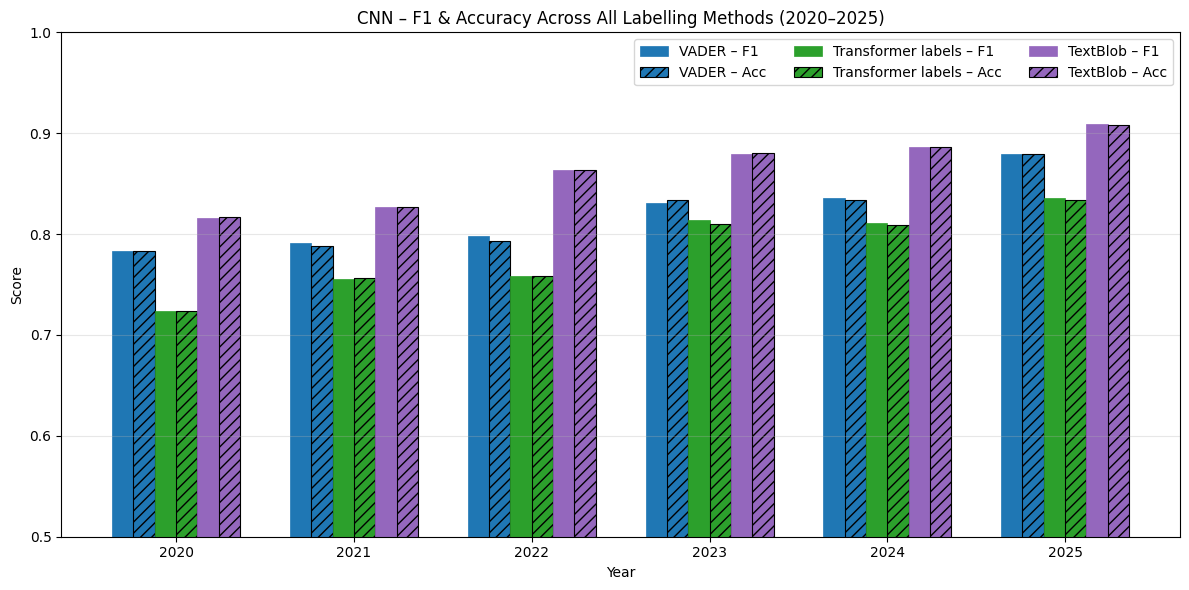

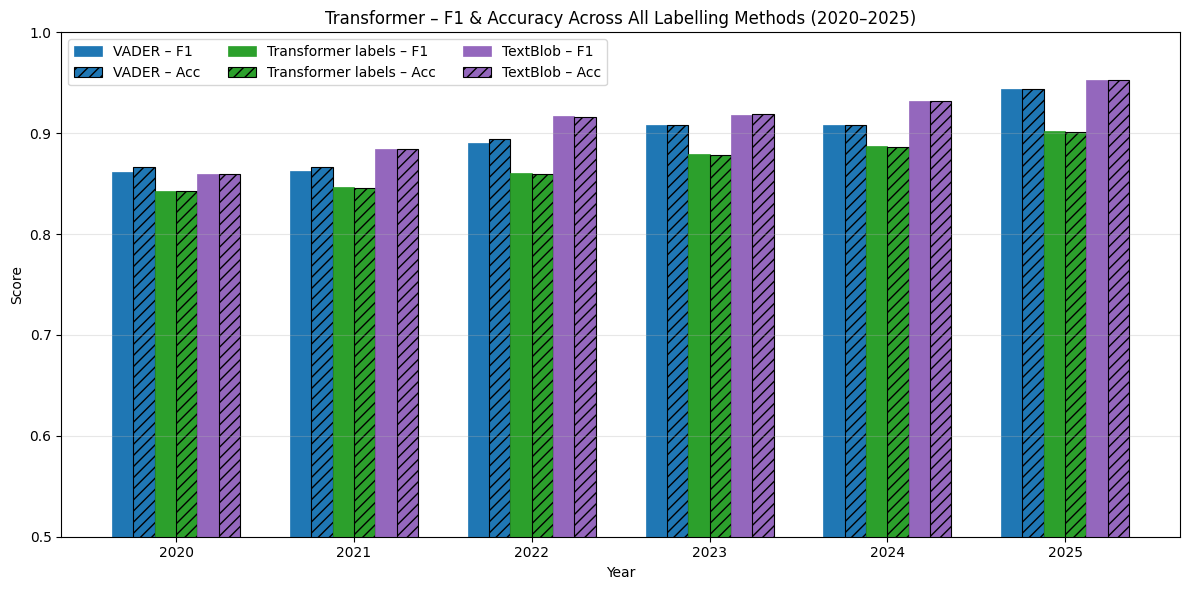

In [27]:
import numpy as np
import matplotlib.pyplot as plt

models = ["Naive Bayes", "SVM", "CNN", "Transformer"]

label_pretty = {
    "vader_sentiment": "VADER",
    "sentiment": "Transformer labels",
    "Blob_Sentiment": "TextBlob"
}
label_order = ["vader_sentiment", "sentiment", "Blob_Sentiment"]

label_colors = {
    "vader_sentiment": "tab:blue",
    "sentiment": "tab:green",
    "Blob_Sentiment": "tab:purple"
}

for model in models:
    sub = df_avg[df_avg["model"] == model].copy()

    years = sorted(sub["year"].unique())
    x = np.arange(len(years))

    width = 0.12

    plt.figure(figsize=(12, 6))

    offset_start = -width * 2.5
    offset = offset_start

    for lab in label_order:
        sub_lab = sub[sub["label_source"] == lab].sort_values("year")

        f1_vals = sub_lab["f1"].tolist()
        acc_vals = sub_lab["accuracy"].tolist()


        bars_f1 = plt.bar(
            x + offset,
            f1_vals,
            width,
            color=label_colors[lab],
            edgecolor=label_colors[lab],
            linewidth=0.5,
            hatch="",
            label=f"{label_pretty[lab]} – F1"
        )
        offset += width


        bars_acc = plt.bar(
            x + offset,
            acc_vals,
            width,
            color=label_colors[lab],
            edgecolor="black",
            linewidth=0.8,
            hatch="///",
            label=f"{label_pretty[lab]} – Acc"
        )
        offset += width

    plt.xlabel("Year")
    plt.ylabel("Score")
    plt.title(f"{model} – F1 & Accuracy Across All Labelling Methods (2020–2025)")
    plt.xticks(x, years)
    plt.ylim(0.5, 1.0)
    plt.grid(axis="y", alpha=0.3)
    plt.legend(ncol=3)
    plt.tight_layout()

    plt.savefig(f"{model.replace(' ', '_').lower()}_f1_accuracy_all_labels_avg.png", dpi=300)
    plt.show()

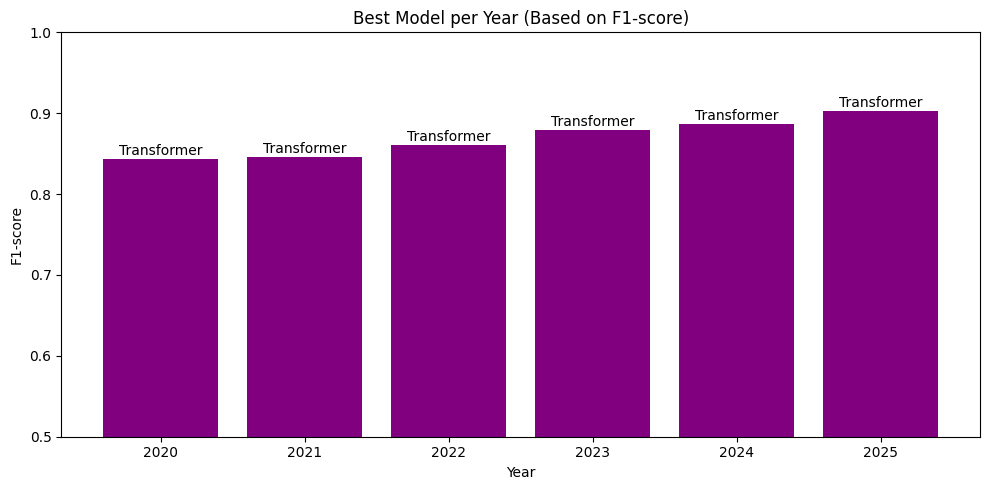

In [ ]:
df_main = df[df["label_source"] == "sentiment"]

best_per_year = df_main.loc[df_main.groupby("year")["f1"].idxmax()]

plt.figure(figsize=(10,5))
plt.bar(best_per_year["year"].astype(str), best_per_year["f1"], color="purple")

for i, v in enumerate(best_per_year["f1"]):
    plt.text(i, v + 0.005, best_per_year.iloc[i]["model"], ha='center')

plt.title("Best Model per Year (Based on F1-score)")
plt.xlabel("Year")
plt.ylabel("F1-score")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig("best_model_per_year.png", dpi=300)


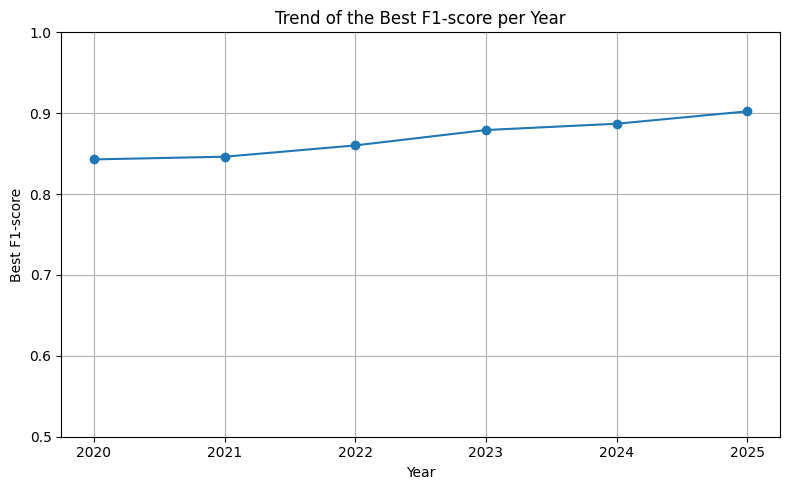

In [ ]:
best_per_year = df_main.loc[df_main.groupby("year")["f1"].idxmax()]

plt.figure(figsize=(8,5))
plt.plot(best_per_year["year"], best_per_year["f1"], marker="o")

plt.title("Trend of the Best F1-score per Year")
plt.xlabel("Year")
plt.ylabel("Best F1-score")
plt.ylim(0.5, 1.0)
plt.grid(True)
plt.tight_layout()
plt.savefig("best_f1_trend.png", dpi=300)

In [ ]:
# Use all data (not df_main) because we want all labelling methods
best_label_per_year = (
    df.loc[df.groupby(["year", "label_nice"])["f1"].max().reset_index()["f1"].groupby(df["year"]).idxmax()]
)

# Simpler + more reliable version:
best_label_per_year = (
    df.loc[df.groupby(["year", "label_nice"])["f1"].idxmax()]
      .sort_values(["year", "f1"], ascending=[True, False])
      .groupby("year")
      .head(1)
)

print(best_label_per_year[["year", "label_nice", "model", "f1"]])

    year label_nice        model      f1
15  2020      VADER  Transformer  0.8618
29  2021   TextBlob  Transformer  0.8844
41  2022   TextBlob  Transformer  0.9168
53  2023   TextBlob  Transformer  0.9185
65  2024   TextBlob  Transformer  0.9319
80  2025   TextBlob  Transformer  0.9525


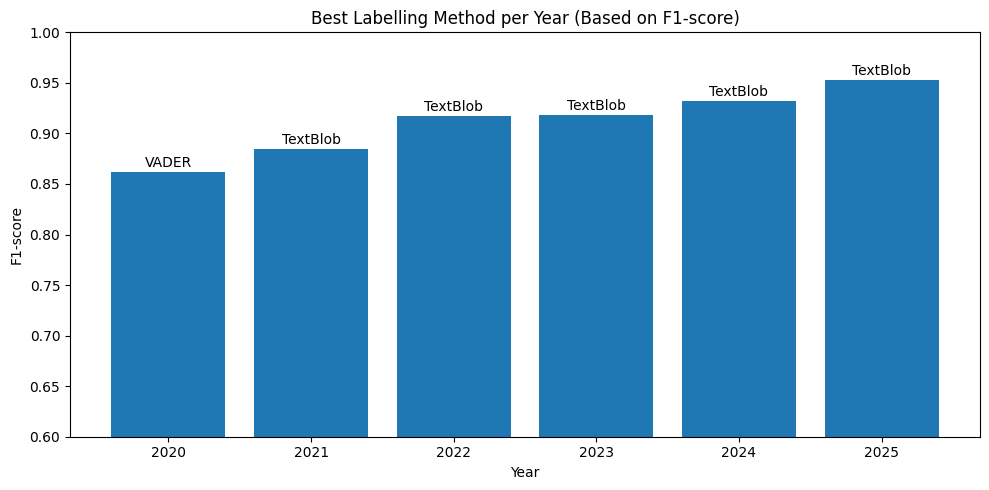

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    best_label_per_year["year"].astype(str),
    best_label_per_year["f1"]
)

# Add label names on top of bars
for i, row in best_label_per_year.iterrows():
    plt.text(
        str(row["year"]),
        row["f1"] + 0.005,
        row["label_nice"],
        ha="center",
        fontsize=10
    )

plt.title("Best Labelling Method per Year (Based on F1-score)")
plt.xlabel("Year")
plt.ylabel("F1-score")
plt.ylim(0.6, 1.0)
plt.tight_layout()
plt.savefig("best_labelling_per_year.png", dpi=300)

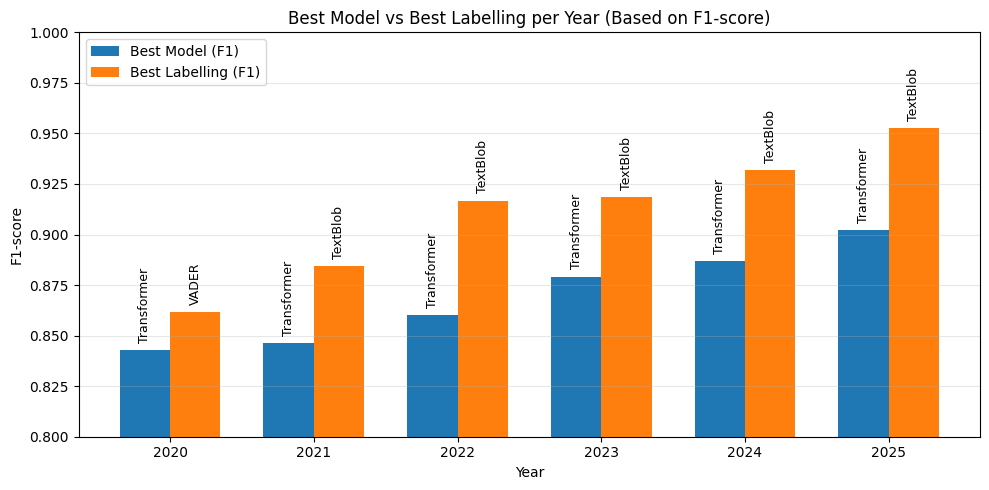

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

years = best_per_year["year"].astype(str).tolist()

best_model_f1 = best_per_year["f1"].tolist()
best_label_f1 = best_label_per_year["f1"].tolist()

best_model_names = best_per_year["model"].tolist()
best_label_names = best_label_per_year["label_nice"].tolist()

x = np.arange(len(years))
width = 0.35

plt.figure(figsize=(10, 5))

# Bars
plt.bar(x - width/2, best_model_f1, width, label="Best Model (F1)")
plt.bar(x + width/2, best_label_f1, width, label="Best Labelling (F1)")

# Text labels on bars
for i in range(len(years)):
    plt.text(x[i] - width/2, best_model_f1[i] + 0.005, best_model_names[i],
             ha="center", fontsize=9, rotation=90)
    plt.text(x[i] + width/2, best_label_f1[i] + 0.005, best_label_names[i],
             ha="center", fontsize=9, rotation=90)

# Formatting
plt.xticks(x, years)
plt.xlabel("Year")
plt.ylabel("F1-score")
plt.title("Best Model vs Best Labelling per Year (Based on F1-score)")
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# Save for thesis
plt.savefig("best_model_vs_best_labelling_merged.png", dpi=300)

plt.show()

#### **Topic Modelling**

#### **LDA**

In [ ]:
LDA_RESULT = [topic_model_2020.loc['LDA', 2020], topic_model_2021.loc['LDA', 2021], topic_model_2022.loc['LDA', 2022], topic_model_2023.loc['LDA', 2020], topic_model_2024.loc['LDA', 2024], topic_model_2025.loc['LDA', 2025]]

In [ ]:
display(LDA_RESULT)

[{'LDA_Sentiment_Summary': {'General Opinions & Daily Experiences': {'Negative': 1156,
    'Neutral': 896,
    'Positive': 614},
   'Jobs, Work & Pay': {'Negative': 1446, 'Neutral': 2267, 'Positive': 1122},
   'Personal Thoughts & Judgements': {'Negative': 1166,
    'Neutral': 1432,
    'Positive': 593},
   'UK & EU Politics': {'Negative': 642, 'Neutral': 1599, 'Positive': 238}}},
 {'LDA_Sentiment_Summary': {'General Frustration & Unreasonable Situations': {'Negative': 1146,
    'Neutral': 1754,
    'Positive': 380},
   'Jobs, Pay & Working Hours': {'Negative': 2512,
    'Neutral': 3887,
    'Positive': 1790},
   'UK Politics': {'Negative': 677, 'Neutral': 1582, 'Positive': 232},
   'Work-Related Feelings & Stress': {'Negative': 3340,
    'Neutral': 1933,
    'Positive': 2061}}},
 {'LDA_Sentiment_Summary': {'Daily Work Life, Pay & Working Hours': {'Negative': 5157,
    'Neutral': 7681,
    'Positive': 3281},
   'Public Frustration, Complaints & Unreasonable Situations': {'Negative': 53

In [ ]:
data = LDA_RESULT
years = [2020, 2021, 2022, 2023, 2024, 2025]

rows = []

for year, item in zip(years, data):
    summary = item.get("LDA_Sentiment_Summary", {})
    for topic, sentiments in summary.items():
        rows.append({
            "Year": year,
            "Topic": topic,
            "Negative": sentiments.get("Negative", 0),
            "Neutral": sentiments.get("Neutral", 0),
            "Positive": sentiments.get("Positive", 0),
        })

df_trend = pd.DataFrame(rows).sort_values(["Year", "Topic"]).reset_index(drop=True)

df_trend

,Year,Topic,Negative,Neutral,Positive
0,2020,General Opinions & Daily Experiences,1156,896,614
1,2020,"Jobs, Work & Pay",1446,2267,1122
2,2020,Personal Thoughts & Judgements,1166,1432,593
3,2020,UK & EU Politics,642,1599,238
4,2021,General Frustration & Unreasonable Situations,1146,1754,380
5,2021,"Jobs, Pay & Working Hours",2512,3887,1790
6,2021,UK Politics,677,1582,232
7,2021,Work-Related Feelings & Stress,3340,1933,2061
8,2022,"Daily Work Life, Pay & Working Hours",5157,7681,3281
9,2022,"Public Frustration, Complaints & Unreasonable ...",5355,3830,2637


#### **Bertopic**

In [ ]:
BERT_RESULT = [
    topic_model_2020.loc['Bertopic', 2020],
    topic_model_2021.loc['Bertopic', 2021],
    topic_model_2022.loc['Bertopic', 2022],
    topic_model_2023.loc['Bertopic', 2020],
    topic_model_2024.loc['Bertopic', 2024],
    topic_model_2025.loc['Bertopic', 2025]
]

years = [2020, 2021, 2022, 2023, 2024, 2025]

rows = []

for year, year_result in zip(years, BERT_RESULT):

    bertopic_topics = year_result["Bertopic"]

    for topic_key, topic_data in bertopic_topics.items():
        if topic_data["topic_id"] == -1:
            continue

        rows.append({
            "Year": year,
            "Topic Label": topic_data["topic_label"],
            "Negative": topic_data["sentiment_distribution"].get("Negative", 0),
            "Positive": topic_data["sentiment_distribution"].get("Positive", 0),
        })

df_bertopic = pd.DataFrame(rows)

df_bertopic = df_bertopic.sort_values(
    by=["Year", "Negative"],
    ascending=[True, False]
).reset_index(drop=True)

df_bertopic

,Year,Topic Label,Negative,Positive
0,2020,COVID-19 & Public Health Crisis,245,202
1,2020,NHS Pay & Healthcare Workforce Crisis,217,121
2,2020,Unemployment & Job Market Struggles,208,190
3,2020,Housing Costs & Cost of Living Crisis,150,105
4,2020,Topic 12,129,65
...,...,...,...,...
479,2025,Topic 170,9,19
480,2025,Topic 144,7,14
481,2025,Topic 175,6,7
482,2025,Topic 137,5,8


In [ ]:
df_bertopic.to_csv(
    "bertopic_topics_per_year.csv",
    index=False
)